# ARIMA Model training

### Importing Libraries

In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df = pd.read_csv("/content/all_bank_stock_data_clean.csv")
df.head(5)

,Date,Bank,Open,High,Low,Close,Volume,GBPUSD,Open_GBX,High_GBX,Low_GBX,Close_GBX
0,2015-01-02,Lloyds,76.103240,76.381896,75.306079,75.784775,54277932,1.557972,76.103240,76.381896,75.306079,75.784775
1,2015-01-05,Lloyds,75.705150,76.033569,74.102872,74.262108,102525515,1.528491,75.705150,76.033569,74.102872,74.262108
2,2015-01-06,Lloyds,74.272069,74.690060,72.520515,72.520515,133810250,1.525832,74.272069,74.690060,72.520515,72.520515
3,2015-01-07,Lloyds,72.968331,73.588344,72.520493,72.659821,108980419,1.513798,72.968331,73.588344,72.520493,72.659821
4,2015-01-08,Lloyds,73.157424,74.063056,72.898669,73.744591,79367070,1.510757,73.157424,74.063056,72.898669,73.744591


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8810 entries, 0 to 8809
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       8810 non-null   object 
 1   Bank       8810 non-null   object 
 2   Open       8810 non-null   float64
 3   High       8810 non-null   float64
 4   Low        8810 non-null   float64
 5   Close      8810 non-null   float64
 6   Volume     8810 non-null   int64  
 7   GBPUSD     8810 non-null   float64
 8   Open_GBX   8810 non-null   float64
 9   High_GBX   8810 non-null   float64
 10  Low_GBX    8810 non-null   float64
 11  Close_GBX  8810 non-null   float64
dtypes: float64(9), int64(1), object(2)
memory usage: 826.1+ KB


In [4]:
df.describe()

,Open,High,Low,Close,Volume,GBPUSD,Open_GBX,High_GBX,Low_GBX,Close_GBX
count,8810.000000,8810.000000,8810.000000,8810.000000,8.810000e+03,8810.000000,8810.000000,8810.000000,8810.000000,8810.000000
mean,195.990944,198.351011,193.694998,196.036426,7.962134e+07,1.321752,8141.568869,8233.817180,8050.537359,8143.971970
std,172.889340,174.988506,170.745241,172.918726,9.743120e+07,0.088391,14818.958893,14996.544100,14639.117887,14821.463185
min,23.976281,24.674426,23.522487,23.916439,4.601000e+05,1.072754,23.976281,24.674426,23.522487,23.916439
25%,68.516438,69.158603,67.717600,68.441130,3.295975e+06,1.262738,68.516438,69.158603,67.717600,68.441130
50%,163.083601,165.206432,161.226708,163.468384,4.131634e+07,1.308575,182.827868,185.438085,181.014703,183.212029
75%,225.987974,228.665890,223.391104,226.350800,1.261622e+08,1.356516,13565.565821,13766.447199,13398.436073,13561.361795
max,1148.420044,1153.989990,1117.400024,1152.069946,7.669057e+08,1.588512,85721.517328,86137.274829,83406.090011,85993.956989


## Load and Clean All Three Banks


In [5]:
BANKS = {
    'Lloyds': '/content/lloyds_bank_stock_data_clean.csv',
    'Barclays': '/content/barclays_bank_stock_data_clean.csv',
    'Goldman Sachs': '/content/gs_bank_stock_data_clean.csv',
}
bank_data = {}
for name, path in BANKS.items():
    bdf = pd.read_csv(path)
    bdf['Date'] = pd.to_datetime(bdf['Date'])
    numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    bdf[numeric_cols] = bdf[numeric_cols].apply(pd.to_numeric)
    bdf = bdf.sort_values('Date').set_index('Date')
    bank_data[name] = bdf

    print(f'--- {name} ---')
    print('shape:', bdf.shape)
    print('missing values:\n', bdf[numeric_cols].isnull().sum().to_string())
    print()

--- Lloyds ---
shape: (2942, 10)
missing values:
 Open      0
High      0
Low       0
Close     0
Volume    0

--- Barclays ---
shape: (2941, 10)
missing values:
 Open      0
High      0
Low       0
Close     0
Volume    0

--- Goldman Sachs ---
shape: (2927, 10)
missing values:
 Open      0
High      0
Low       0
Close     0
Volume    0



In [6]:
for name, bdf in bank_data.items():
    print(name)
    display(bdf[['Open', 'High', 'Low', 'Close', 'Volume']].head(3))

Lloyds


,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,76.103240,76.381896,75.306079,75.784775,54277932
2015-01-05,75.705150,76.033569,74.102872,74.262108,102525515
2015-01-06,74.272069,74.690060,72.520515,72.520515,133810250


Barclays


,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,241.407284,244.796165,240.759418,242.354172,20219711
2015-01-05,241.506939,242.354148,233.433445,233.931808,39050852
2015-01-06,233.283941,235.078052,229.496375,229.596054,37573308


Goldman Sachs


,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,155.581634,155.924179,153.510394,154.872635,1877700
2015-01-05,153.797184,154.577877,149.351993,150.037094,3413200
2015-01-06,150.005248,150.292035,146.523971,147.001953,3429200


## ARIMA Pipeline Functions

In [7]:
def adf_test(series, name=''):
    """Augmented Dickey-Fuller test for stationarity."""
    result = adfuller(series)
    print(f"[{name}] ADF Statistic: {result[0]:.4f}   p-value: {result[1]:.6g}")
    is_stationary = result[1] <= 0.05
    conclusion = 'stationary' if is_stationary else 'non-stationary (differencing required)'
    print(f"[{name}] Conclusion: series is {conclusion}")
    return is_stationary, result

In [8]:
def plot_acf_pacf(diff_series, name='', lags=40):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(diff_series, lags=lags, ax=axes[0])
    axes[0].set_title(f'ACF - {name} (differenced)')
    plot_pacf(diff_series, lags=lags, ax=axes[1])
    axes[1].set_title(f'PACF - {name} (differenced)')
    plt.tight_layout()
    plt.show()

In [9]:
def grid_search_arima(train, d=1, p_range=range(6), q_range=range(6), label=''):
    best_aic, best_order, best_model = float('inf'), None, None
    for p in p_range:
        for q in q_range:
            try:
                fit = ARIMA(train, order=(p, d, q)).fit()
                if fit.aic < best_aic:
                    best_aic, best_order, best_model = fit.aic, (p, d, q), fit
            except Exception:
                continue
    print(f"[{label}] Best order: {best_order}   AIC: {best_aic:.2f}")
    return best_model, best_order, best_aic

In [10]:
def forecast_arima(train, test, order, refit_every=1, max_jump=0.5, label=''):
    history = list(train)
    predictions = []
    diverged_steps = []
    model_fit = None
    for step, actual in enumerate(test):
        if model_fit is None or step % refit_every == 0:
            model_fit = ARIMA(history, order=order).fit()
        yhat = model_fit.forecast()[0]
        last_value = history[-1]
        if last_value != 0 and abs(yhat - last_value) / abs(last_value) > max_jump:
            diverged_steps.append((step, yhat))
            yhat = last_value
        predictions.append(yhat)
        history.append(actual)

    print(f"[{label}] walk-forward complete; {len(diverged_steps)} of {len(test)} steps corrected for divergence")
    forecast_series = pd.Series(predictions, index=test.index)
    return forecast_series, diverged_steps

In [11]:
def evaluate_forecast(test, forecast):
    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mape = np.mean(np.abs((test - forecast) / test)) * 100
    r2 = r2_score(test, forecast)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

In [12]:
def plot_actual_vs_predicted(test, forecast, name=''):
    plt.figure(figsize=(10, 5))
    plt.plot(test.index, test, label='Actual')
    plt.plot(test.index, forecast, label='Predicted')
    plt.title(f'{name} - Actual vs Predicted Closing Price')
    plt.xlabel('Date')
    plt.ylabel('Closing Price')
    plt.legend()
    plt.show()

def plot_residual_diagnostics(test, forecast, name=''):
    residuals = test.values - forecast.values
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(residuals, bins=40)
    axes[0].set_title(f'{name} - Residual Distribution')
    axes[0].set_xlabel('Residual')
    plot_acf(residuals, lags=min(30, len(residuals) - 1), ax=axes[1])
    axes[1].set_title(f'{name} - Residual Autocorrelation')
    plt.tight_layout()
    plt.show()

## Run the Pipeline for All Three Banks

Lloyds
[Lloyds (level)] ADF Statistic: -0.2625   p-value: 0.930644
[Lloyds (level)] Conclusion: series is non-stationary (differencing required)
[Lloyds (differenced)] ADF Statistic: -12.1275   p-value: 1.76697e-22
[Lloyds (differenced)] Conclusion: series is stationary


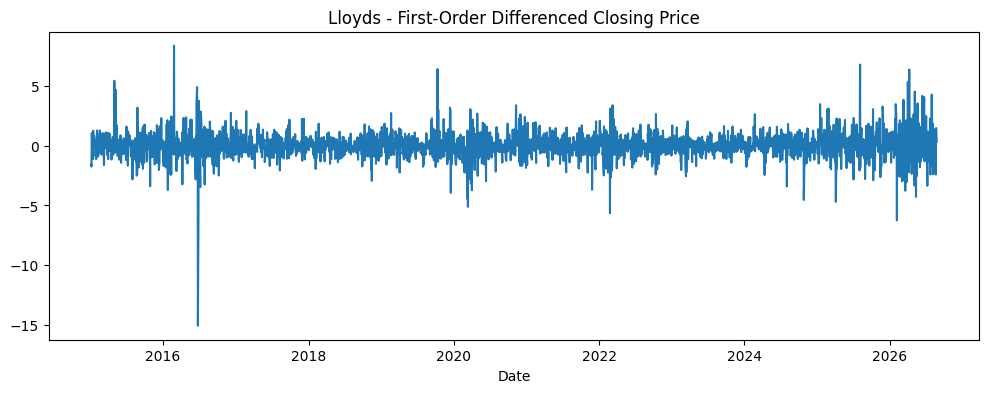

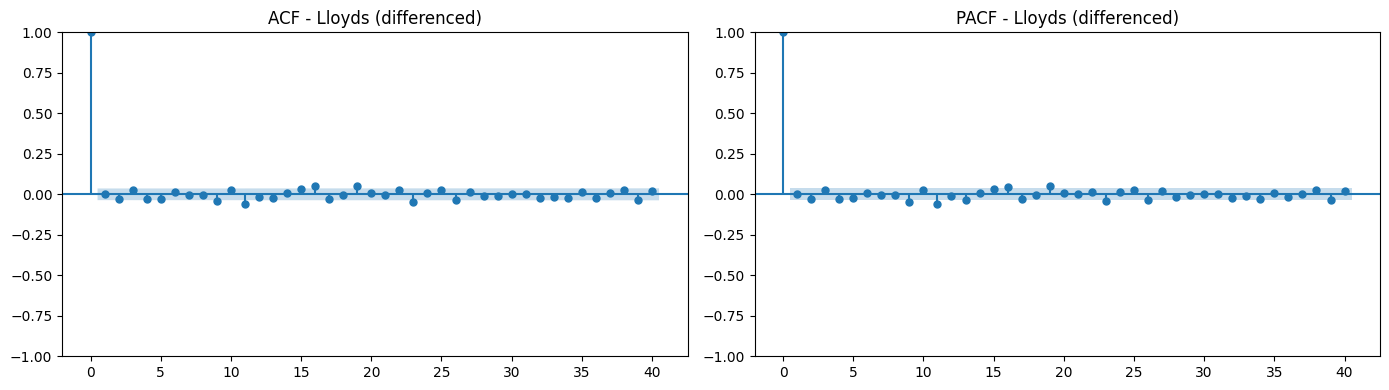

[Lloyds] train=2353  test=589
[Lloyds] Best order: (3, 1, 4)   AIC: 6634.02
[Lloyds] walk-forward complete; 0 of 589 steps corrected for divergence
[Lloyds] MAE=0.971  RMSE=1.365  MAPE=1.221%  R2=0.99513


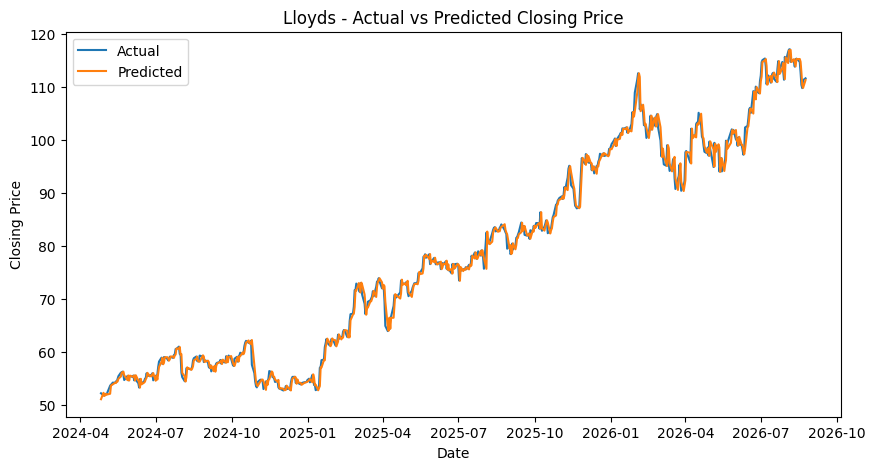

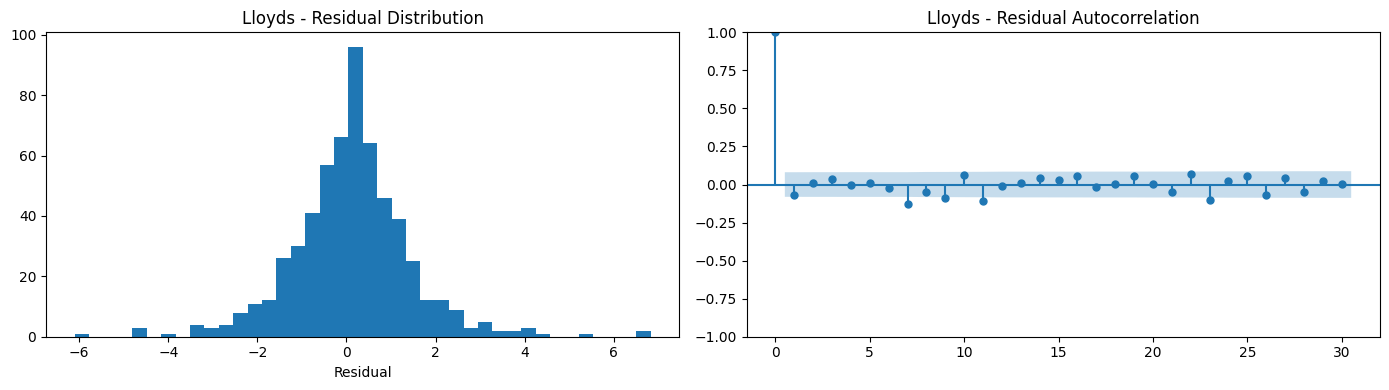

[Lloyds] total time (grid search + walk-forward): 2060.4s

Barclays
[Barclays (level)] ADF Statistic: 0.5528   p-value: 0.986393
[Barclays (level)] Conclusion: series is non-stationary (differencing required)
[Barclays (differenced)] ADF Statistic: -39.8173   p-value: 0
[Barclays (differenced)] Conclusion: series is stationary


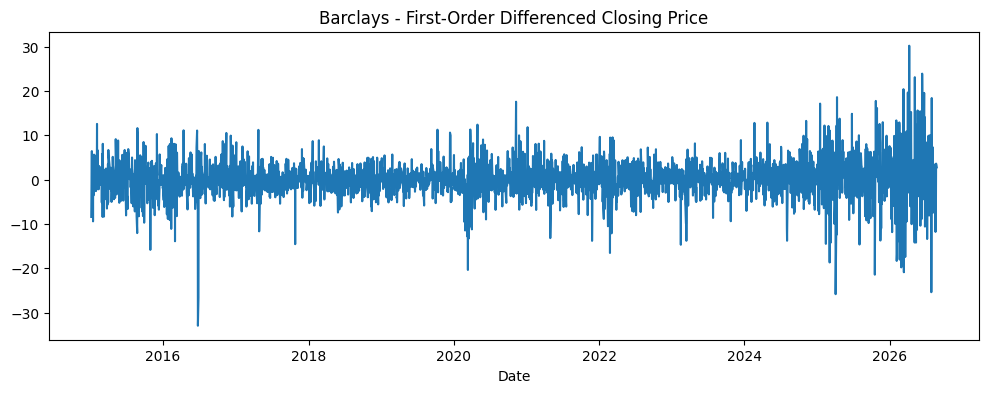

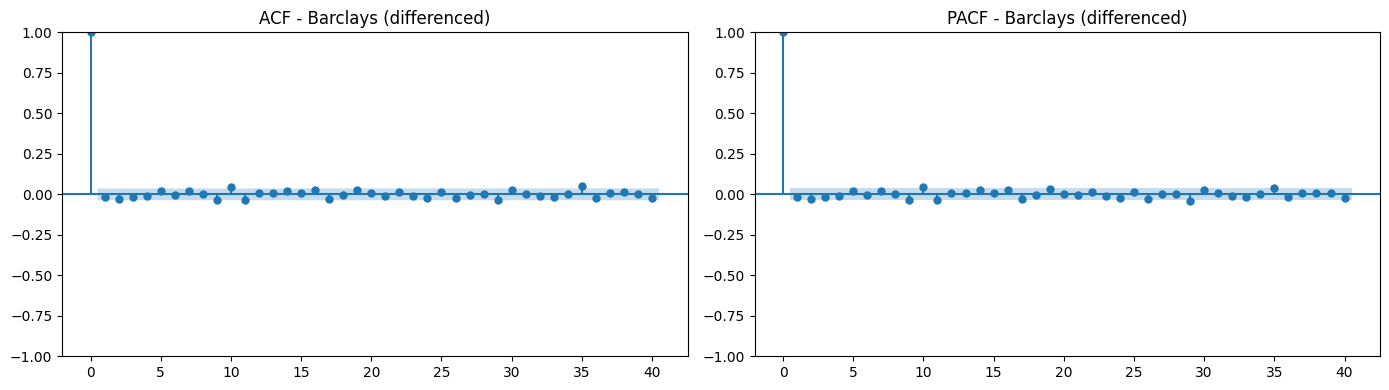

[Barclays] train=2352  test=589
[Barclays] Best order: (0, 1, 0)   AIC: 12599.33
[Barclays] walk-forward complete; 0 of 589 steps corrected for divergence
[Barclays] MAE=5.039  RMSE=6.871  MAPE=1.468%  R2=0.99516


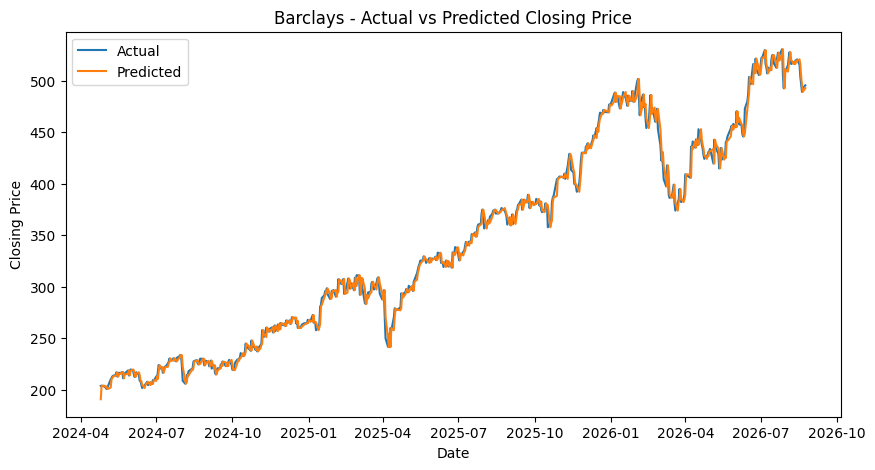

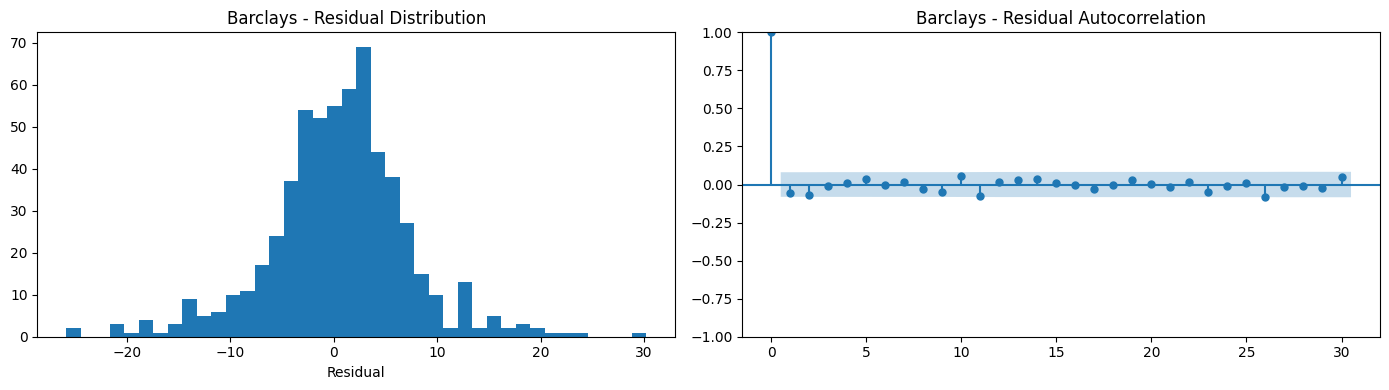

[Barclays] total time (grid search + walk-forward): 77.6s

Goldman Sachs
[Goldman Sachs (level)] ADF Statistic: 2.6013   p-value: 0.999075
[Goldman Sachs (level)] Conclusion: series is non-stationary (differencing required)
[Goldman Sachs (differenced)] ADF Statistic: -10.6350   p-value: 5.09803e-19
[Goldman Sachs (differenced)] Conclusion: series is stationary


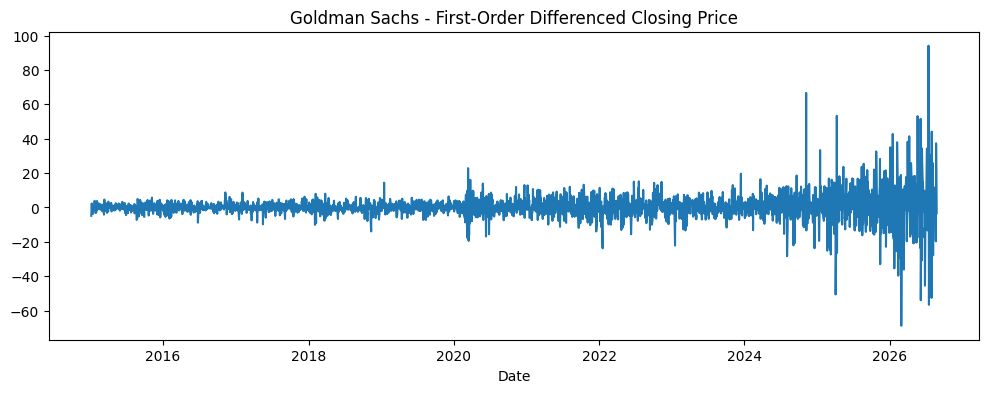

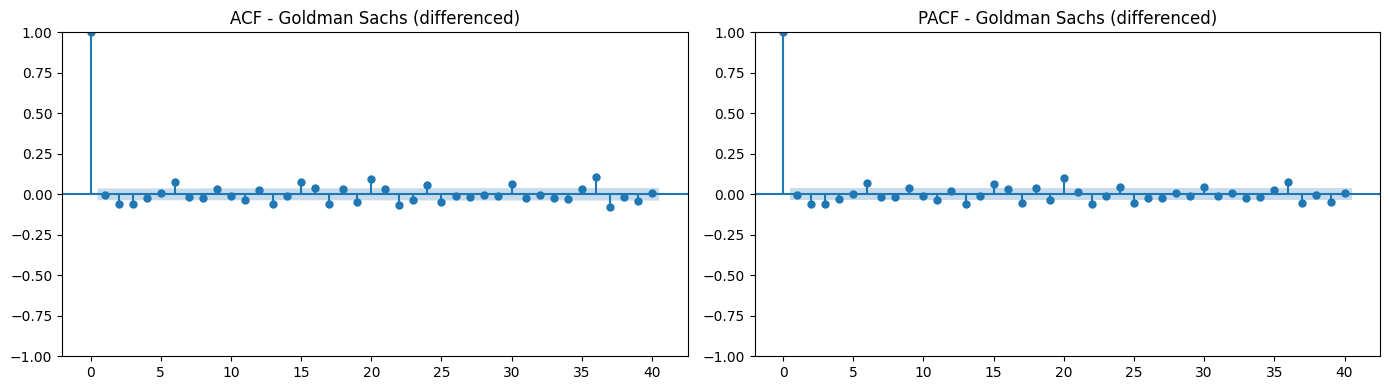

[Goldman Sachs] train=2341  test=586
[Goldman Sachs] Best order: (2, 1, 2)   AIC: 13042.56
[Goldman Sachs] walk-forward complete; 0 of 586 steps corrected for divergence
[Goldman Sachs] MAE=9.872  RMSE=14.576  MAPE=1.388%  R2=0.99471


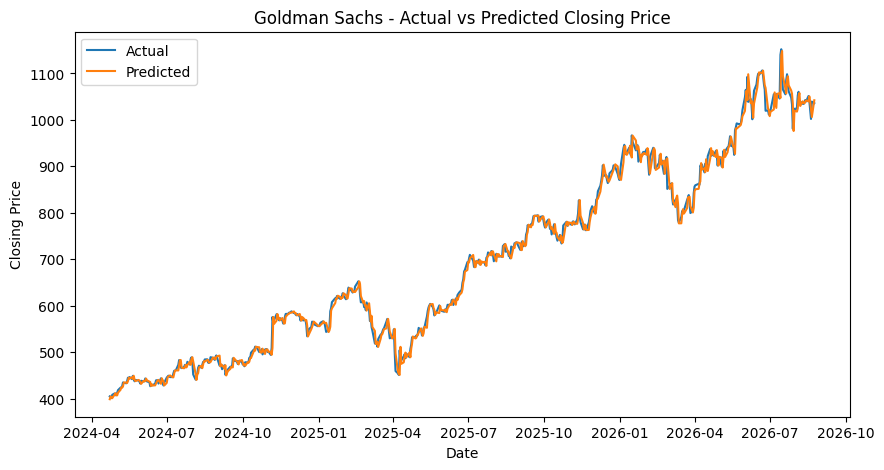

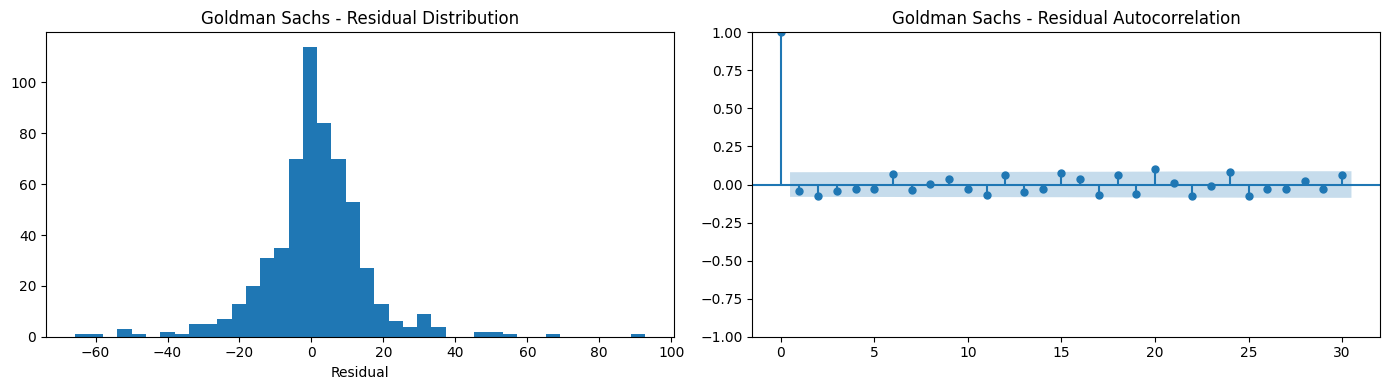

[Goldman Sachs] total time (grid search + walk-forward): 1218.8s



In [13]:
results = {}
for name, bdf in bank_data.items():
    print('=' * 70)
    print(name)
    print('=' * 70)
    bank_start_time = time.time()
    series = bdf['Close']

    # Stationarity
    is_stationary, _ = adf_test(series, name=f'{name} (level)')
    d = 0 if is_stationary else 1
    diff_series = series.diff().dropna() if d == 1 else series
    if d == 1:
        adf_test(diff_series, name=f'{name} (differenced)')
    plt.figure(figsize=(12, 4))
    plt.plot(diff_series.index, diff_series)
    plt.title(f'{name} - First-Order Differenced Closing Price' if d == 1 else f'{name} - Closing Price (already stationary)')
    plt.xlabel('Date')
    plt.show()

    # ACF / PACF
    plot_acf_pacf(diff_series, name=name)

    # Train/test split (80/20, time-ordered)
    train_size = int(len(series) * 0.8)
    train, test = series[:train_size], series[train_size:]
    print(f'[{name}] train={len(train)}  test={len(test)}')

    # Grid search (AIC-scored) - timed together with walk-forward below,
    best_model, best_order, best_aic = grid_search_arima(train, d=d, label=name)

    # Walk-forward forecast
    forecast, diverged_steps = forecast_arima(train, test, best_order, label=name)

    # Evaluation
    metrics = evaluate_forecast(test, forecast)
    print(f"[{name}] MAE={metrics['MAE']:.3f}  RMSE={metrics['RMSE']:.3f}  "
          f"MAPE={metrics['MAPE']:.3f}%  R2={metrics['R2']:.5f}")

    # Diagnostic plots
    plot_actual_vs_predicted(test, forecast, name=name)
    plot_residual_diagnostics(test, forecast, name=name)
    training_time = time.time() - bank_start_time
    print(f"[{name}] total time (grid search + walk-forward): {training_time:.1f}s")
    results[name] = {
        'Bank': name,
        'Order': best_order,
        'AIC': best_aic,
        'Diverged_Steps': len(diverged_steps),
        'Training_Time_Sec': training_time,
        **metrics,
        'model': best_model,
        'forecast': forecast,
        'test': test,
        'train': train,
    }
    print()

### Combined Actual vs Predicted (All Three Banks)

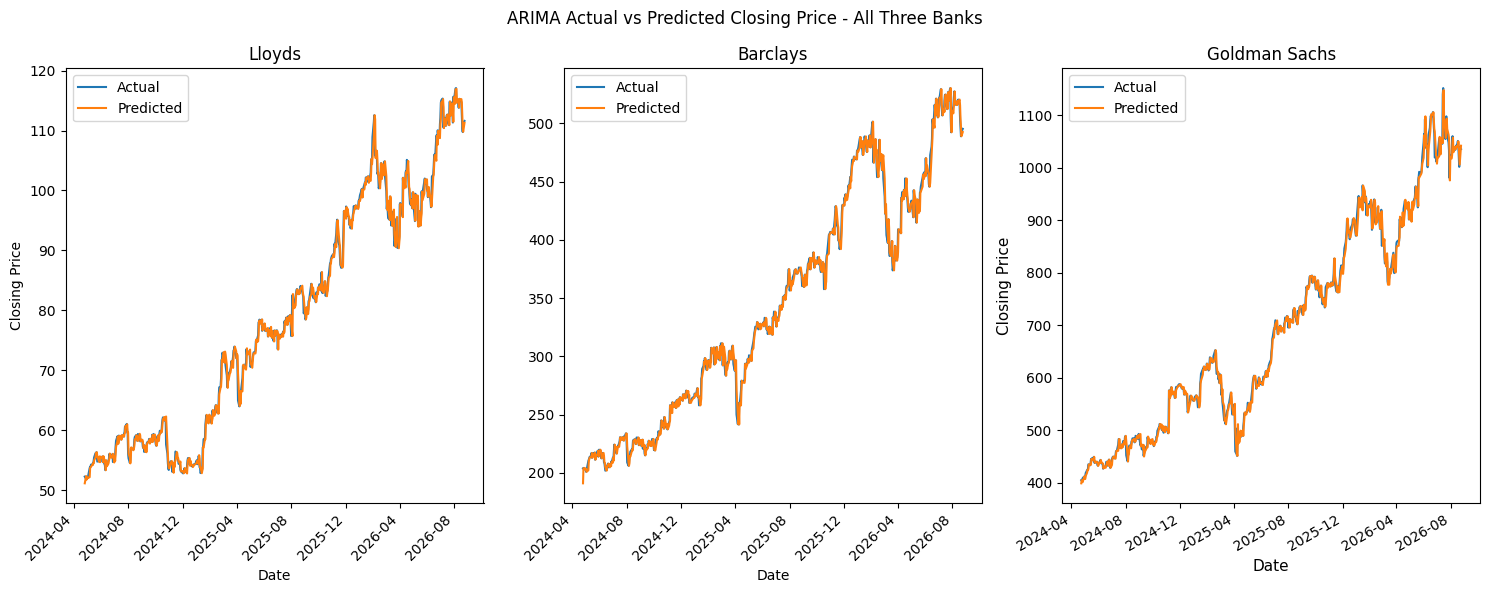

In [14]:
import matplotlib.dates as mdates
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax, (name, r) in zip(axes, results.items()):
    test, forecast = r['test'], r['forecast']
    ax.plot(test.index, test, label='Actual')
    ax.plot(test.index, forecast, label='Predicted')
    ax.set_title(name)
    ax.set_xlabel('Date')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    ax.legend()

axes[0].set_ylabel('Closing Price')
fig.suptitle('ARIMA Actual vs Predicted Closing Price - All Three Banks')
plt.xticks(fontsize=10, rotation=30)
plt.yticks(fontsize=10)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Closing Price", fontsize=11)
plt.tight_layout()
plt.show()

In [15]:
for name, r in results.items():
    print('-' * 70)
    print(f"{name} - ARIMA{r['Order']}")
    print('-' * 70)
    print(r['model'].summary())
    print()

----------------------------------------------------------------------
Lloyds - ARIMA(3, 1, 4)
----------------------------------------------------------------------
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2353
Model:                 ARIMA(3, 1, 4)   Log Likelihood               -3309.012
Date:                Wed, 26 Aug 2026   AIC                           6634.024
Time:                        22:55:04   BIC                           6680.128
Sample:                             0   HQIC                          6650.814
                               - 2353                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4426      0.218      2.028 

## Persistence Baseline

In [16]:
def evaluate_persistence(test, label=''):
    predicted = test.shift(1)
    predicted.iloc[0] = train.iloc[-1] if 'train' in dir() else test.iloc[0]

    actual = test
    valid = predicted.notna()

    mae = mean_absolute_error(actual[valid], predicted[valid])
    rmse = np.sqrt(mean_squared_error(actual[valid], predicted[valid]))
    mape = np.mean(np.abs((actual[valid] - predicted[valid]) / actual[valid])) * 100
    r2 = r2_score(actual[valid], predicted[valid])

    actual_direction = np.sign(actual.diff())
    predicted_direction = np.sign(predicted.diff())
    directional_accuracy = (actual_direction == predicted_direction).mean() * 100

    print(f"[{label}] Persistence: MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.3f}%  "
          f"R2={r2:.5f}  Directional Accuracy={directional_accuracy:.1f}%")

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2,
            'Directional_Accuracy': directional_accuracy}

In [17]:
persistence_results = {}

for name, r in results.items():
    train = r['train']
    test = r['test']
    persistence_results[name] = evaluate_persistence(test, label=name)
    forecast = r['forecast']
    actual_direction = np.sign(test.diff())
    forecast_direction = np.sign(pd.Series(forecast.values, index=test.index).diff())
    arima_directional_accuracy = (actual_direction == forecast_direction).mean() * 100
    persistence_results[name]['ARIMA_Directional_Accuracy'] = arima_directional_accuracy
    print(f"[{name}] ARIMA Directional Accuracy={arima_directional_accuracy:.1f}%\n")

[Lloyds] Persistence: MAE=0.957  RMSE=1.354  MAPE=1.200%  R2=0.99521  Directional Accuracy=46.2%
[Lloyds] ARIMA Directional Accuracy=46.0%

[Barclays] Persistence: MAE=5.018  RMSE=6.851  MAPE=1.458%  R2=0.99519  Directional Accuracy=44.8%
[Barclays] ARIMA Directional Accuracy=45.0%

[Goldman Sachs] Persistence: MAE=9.813  RMSE=14.558  MAPE=1.379%  R2=0.99472  Directional Accuracy=49.1%
[Goldman Sachs] ARIMA Directional Accuracy=48.1%



In [18]:
persistence_df = pd.DataFrame([
    {'Bank': name, 'Model': 'Persistence', **{k: v for k, v in r.items() if k != 'ARIMA_Directional_Accuracy'}}
    for name, r in persistence_results.items()
])
persistence_df.to_csv('persistence_results_summary.csv', index=False)
print('Saved persistence_results_summary.csv')
persistence_df

Saved persistence_results_summary.csv


,Bank,Model,MAE,RMSE,MAPE,R2,Directional_Accuracy
0,Lloyds,Persistence,0.957326,1.353591,1.200122,0.995207,46.179966
1,Barclays,Persistence,5.017606,6.850678,1.457519,0.995185,44.821732
2,Goldman Sachs,Persistence,9.812858,14.558165,1.379447,0.994725,49.146758


## Comparison of ARIMA Models

In [19]:
all_results = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('model', 'forecast', 'test', 'train')}
    for r in results.values()
])
all_results

,Bank,Order,AIC,Diverged_Steps,Training_Time_Sec,MAE,RMSE,MAPE,R2
0,Lloyds,"(3, 1, 4)",6634.024184,0,2060.441727,0.971179,1.364817,1.221300,0.995127
1,Barclays,"(0, 1, 0)",12599.331427,0,77.562391,5.039426,6.871115,1.468221,0.995156
2,Goldman Sachs,"(2, 1, 2)",13042.557679,0,1218.839367,9.872191,14.576095,1.387950,0.994712


### Visualizing Comparison of Metrics

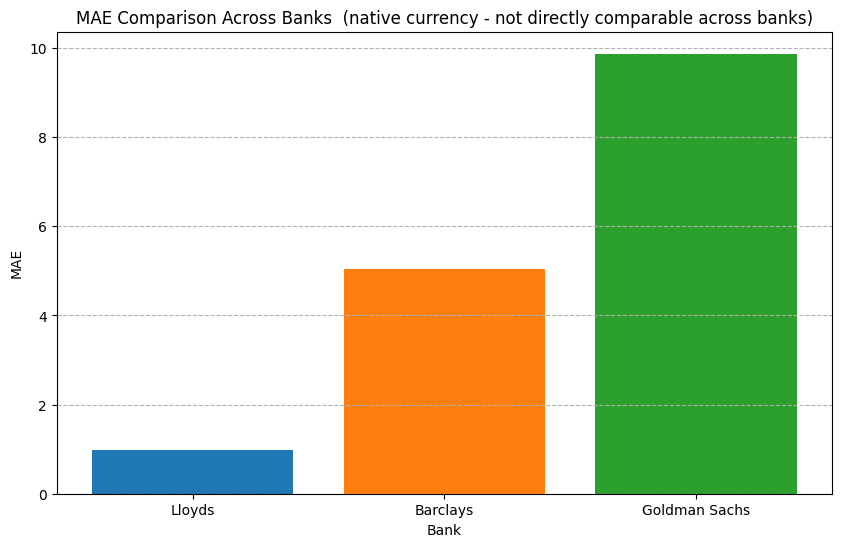

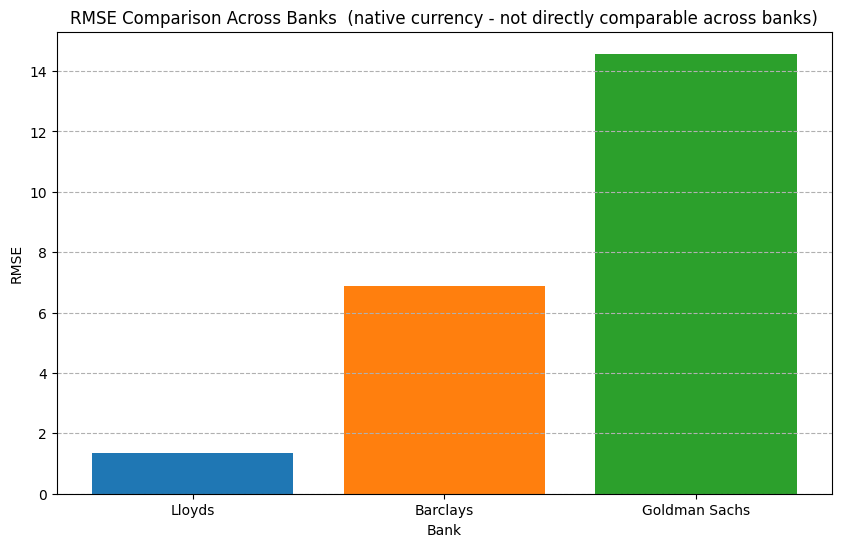

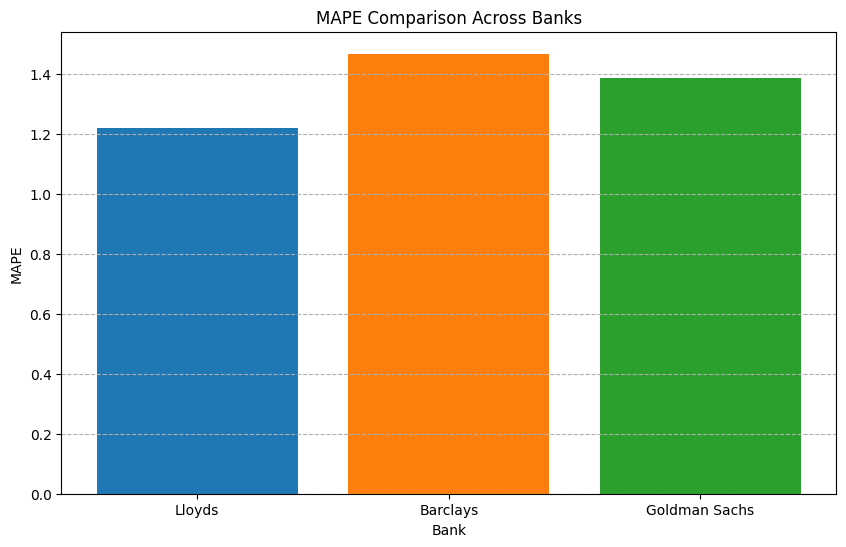

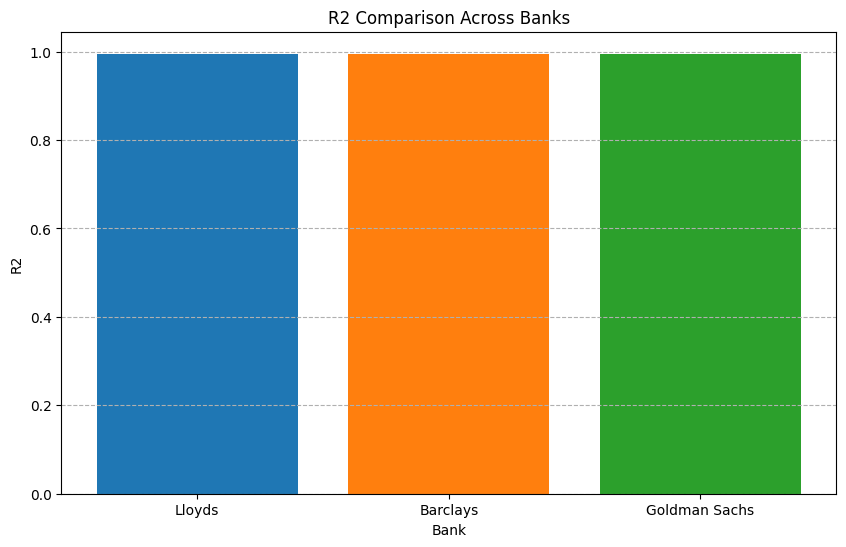

In [20]:
not_comparable = {'MAE', 'RMSE'}
metrics_to_plot = ['MAE', 'RMSE', 'MAPE', 'R2']

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 6))
    plt.bar(all_results['Bank'], all_results[metric], color=['tab:blue', 'tab:orange', 'tab:green'])
    plt.xlabel('Bank')
    plt.ylabel(metric)
    title = f'{metric} Comparison Across Banks'
    if metric in not_comparable:
        title += '  (native currency - not directly comparable across banks)'
    plt.title(title)
    plt.grid(axis='y', linestyle='--')
    plt.show()

### Comparison Table (Heatmap)

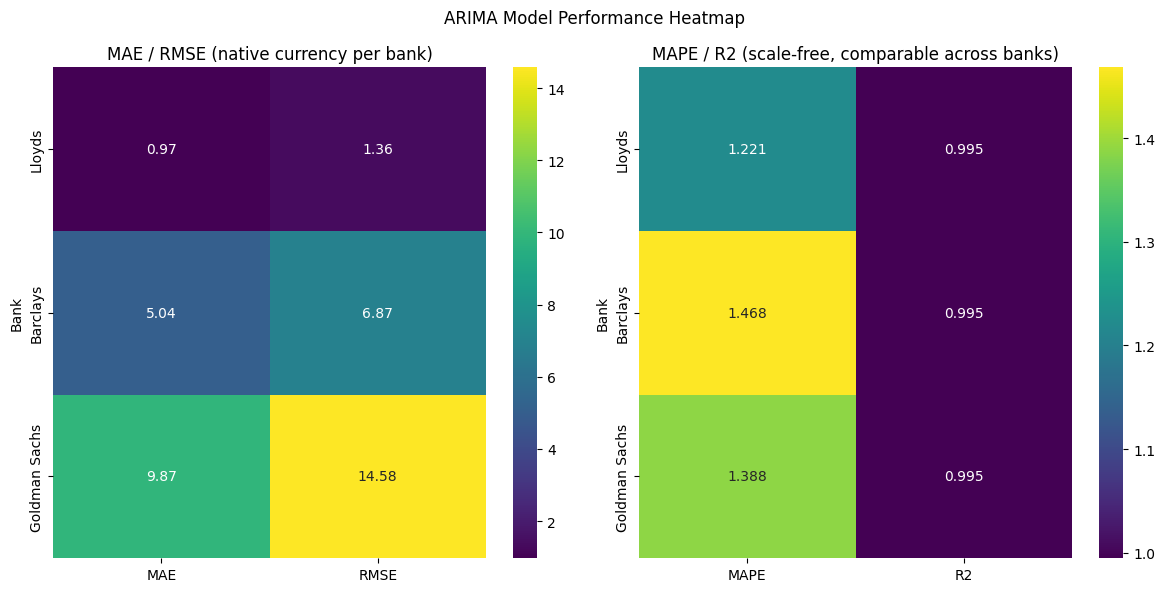

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(
    all_results.set_index('Bank')[['MAE', 'RMSE']],
    annot=True, cmap='viridis', fmt=".2f", ax=axes[0]
)
axes[0].set_title('MAE / RMSE (native currency per bank)')

sns.heatmap(
    all_results.set_index('Bank')[['MAPE', 'R2']],
    annot=True, cmap='viridis', fmt=".3f", ax=axes[1]
)
axes[1].set_title('MAPE / R2 (scale-free, comparable across banks)')

fig.suptitle('ARIMA Model Performance Heatmap')
plt.tight_layout()
plt.show()

In [22]:
all_results_export = all_results.drop(columns=['Order']).copy()
all_results_export.insert(1, 'Model', 'ARIMA')
all_results_export.to_csv('arima_results_summary.csv', index=False)
print('Saved arima_results_summary.csv')
all_results_export

Saved arima_results_summary.csv


,Bank,Model,AIC,Diverged_Steps,Training_Time_Sec,MAE,RMSE,MAPE,R2
0,Lloyds,ARIMA,6634.024184,0,2060.441727,0.971179,1.364817,1.221300,0.995127
1,Barclays,ARIMA,12599.331427,0,77.562391,5.039426,6.871115,1.468221,0.995156
2,Goldman Sachs,ARIMA,13042.557679,0,1218.839367,9.872191,14.576095,1.387950,0.994712
